# The Free Month A/B Experiment: Analysis Notebook

**Date:** April 17, 2026  
**Author:** John Tribbia

This notebook evaluates whether offering a free first month to users who had not converted after three months increased paid conversion relative to a control group.

The analysis uses `data/chatgpt_ab_test.csv`, covering 10,000 treatment users and 20,000 control users observed across June and July 2023.

The sections below check group balance, compare conversion and revenue outcomes, and estimate whether the promotion produced a meaningful lift.

## Setup


In [1]:
import csv
import math
import os
from collections import defaultdict
from datetime import datetime, timedelta

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E7EBF0', 'grid.linewidth': 0.5,
    'figure.dpi': 120,
})

DATA_PATH = 'data/chatgpt_ab_test.csv'
CUTOFF    = datetime(2023, 7, 1)   # in-window cutoff: signup + 30 days ≤ July 31
OBS_END   = datetime(2023, 7, 31)
PRICE     = 20.0                   # $20/month plan price

def parse(s):
    return datetime.strptime(s, '%Y-%m-%d') if s else None

In [2]:
rows  = list(csv.DictReader(open(DATA_PATH)))
treat = [r for r in rows if r['treatment'] == '1']
ctrl  = [r for r in rows if r['treatment'] == '0']

print(f'{len(rows):,} rows  ({len(treat):,} T / {len(ctrl):,} C,  {len(treat)/len(ctrl):.1f}:1 allocation)')
print(f'Date range: {min(r["assignment_date"] for r in rows)}  to  {max(r["assignment_date"] for r in rows)}')
print(f'Columns:    {list(rows[0].keys())}')


30,000 rows  (10,000 T / 20,000 C,  0.5:1 allocation)
Date range: 2023-06-01  to  2023-07-31
Columns:    ['user_id', 'assignment_date', 'treatment', 'assigned_on_platform', 'time_zone', 'paid_plan_canceled', 'paid_signup_date']


## Q1 — Signup lift

Two-proportion z-test. The 1:2 allocation is intentional and fine — the z-test handles unequal group sizes naturally, and it gives a more precise control estimate at minimal cost to power. At n=30,000 this experiment is well over-powered for a 1 pp effect, so significance was never going to be the limiting factor.


In [3]:
n_t = len(treat)
n_c = len(ctrl)
s_t = sum(1 for r in treat if r['paid_signup_date'])
s_c = sum(1 for r in ctrl  if r['paid_signup_date'])
p_t, p_c = s_t / n_t, s_c / n_c
lift     = p_t - p_c
se_t     = math.sqrt(p_t * (1 - p_t) / n_t)
se_c     = math.sqrt(p_c * (1 - p_c) / n_c)
se_d     = math.sqrt(se_t**2 + se_c**2)
z1       = lift / se_d
ci1      = (lift - 1.96 * se_d, lift + 1.96 * se_d)

print(f'Treatment: {s_t:,}/{n_t:,} = {p_t*100:.2f}%')
print(f'Control:   {s_c:,}/{n_c:,} = {p_c*100:.2f}%')
print()
print(f'Lift:    +{lift*100:.2f} pp  (+{lift/p_c*100:.1f}% relative)')
print(f'95% CI:  [{ci1[0]*100:+.2f}, {ci1[1]*100:+.2f}] pp')
print(f'z = {z1:.2f}   p < 0.001')
print()
print(f'Incremental signups per 10k treated:    ~{lift*n_t:.0f}')
print(f'Non-incremental (would have converted): ~{p_c*n_t:.0f}')
print(f'Deadweight ratio: {p_c/lift:.1f}x')


Treatment: 966/10,000 = 9.66%
Control:   1,592/20,000 = 7.96%

Lift:    +1.70 pp  (+21.4% relative)
95% CI:  [+1.01, +2.39] pp
z = 4.83   p < 0.001

Incremental signups per 10k treated:    ~170
Non-incremental (would have converted): ~796
Deadweight ratio: 4.7x


### Primary outcomes summary


In [8]:
# Retention vars (p_tc, p_cc, diff_r, z_r, pval_r, ci_r, t_in, c_in) computed in Q2 below.
# Run this cell after Q2 if executing out of order.

header = f'  {"Metric":<28}  {"T":>8}  {"C":>8}  {"Diff":>10}  {"z":>6}  {"p":>7}  95% CI'
print(header)
print('-' * len(header))
print(f'  {"Signup rate":<28}  {p_t*100:>7.2f}%  {p_c*100:>7.2f}%  {lift*100:>+9.2f}pp  {z1:>6.2f}  <0.001  [{ci1[0]*100:+.2f}, {ci1[1]*100:+.2f}]')
print(f'  {"Cancel rate (in-window)":<28}  {p_tc*100:>7.1f}%  {p_cc*100:>7.1f}%  {diff_r*100:>+9.1f}pp  {z_r:>6.2f}  {pval_r:>6.3f}  [{ci_r[0]*100:+.1f}, {ci_r[1]*100:+.1f}]')
print()
print(f'In-window cohort: signed up on or before July 1  (n = {len(t_in)} T, {len(c_in)} C)')


  Metric                               T         C        Diff       z        p  95% CI
---------------------------------------------------------------------------------------
  Signup rate                      9.66%     7.96%      +1.70pp    4.83  <0.001  [+1.01, +2.39]
  Cancel rate (in-window)          71.3%     69.9%       +1.3pp    0.43   0.667  [-4.7, +7.3]

In-window cohort: signed up on or before July 1  (n = 334 T, 642 C)


## Q2 — Retention

The raw cancellation numbers look reasonable at first glance. They're not — work through the censoring problem before reading the corrected figures.


### Raw cancellation


In [4]:
st_all = [r for r in treat if r['paid_signup_date']]
sc_all = [r for r in ctrl  if r['paid_signup_date']]

ct_raw = sum(1 for r in st_all if r['paid_plan_canceled'] == '1')
cc_raw = sum(1 for r in sc_all if r['paid_plan_canceled'] == '1')
pt_raw = ct_raw / len(st_all)
pc_raw = cc_raw / len(sc_all)

print(f'Treatment: {ct_raw}/{len(st_all)} = {pt_raw*100:.1f}% canceled')
print(f'Control:   {cc_raw}/{len(sc_all)} = {pc_raw*100:.1f}% canceled')


Treatment: 487/966 = 50.4% canceled
Control:   795/1592 = 49.9% canceled


### Why that number is an artifact


In [5]:
# Treatment signups where the 30-day trial expires after the obs window closes
t_censored = [r for r in st_all if parse(r['paid_signup_date']) > CUTOFF]
t_inwindow  = [r for r in st_all if parse(r['paid_signup_date']) <= CUTOFF]

print(f'Treatment signups: {len(st_all)}')
print(f'  signed up > July 1:  {len(t_censored)}  ({len(t_censored)/len(st_all)*100:.1f}%)  — trial expires in August')
print(f'  signed up <= July 1: {len(t_inwindow)}  ({len(t_inwindow)/len(st_all)*100:.1f}%)  — trial fully elapsed')
print()

t_cens_cancel = sum(1 for r in t_censored if r['paid_plan_canceled'] == '1')
t_win_cancel  = sum(1 for r in t_inwindow  if r['paid_plan_canceled'] == '1')
print(f'Cancel rate, censored signups:  {t_cens_cancel}/{len(t_censored)} = {t_cens_cancel/len(t_censored)*100:.1f}%')
print(f'Cancel rate, in-window signups: {t_win_cancel}/{len(t_inwindow)} = {t_win_cancel/len(t_inwindow)*100:.1f}%')
print()

# The control arm shows the exact same pattern, no offer involved — useful sanity check
c_jun = [r for r in sc_all if parse(r['paid_signup_date']) <= datetime(2023, 6, 30)]
c_jul = [r for r in sc_all if parse(r['paid_signup_date']) >  datetime(2023, 6, 30)]
c_jun_c = sum(1 for r in c_jun if r['paid_plan_canceled'] == '1')
c_jul_c = sum(1 for r in c_jul if r['paid_plan_canceled'] == '1')
print('Control arm (same pattern, no offer involved):')
print(f'  June signups: {c_jun_c}/{len(c_jun)} = {c_jun_c/len(c_jun)*100:.1f}%')
print(f'  July signups: {c_jul_c}/{len(c_jul)} = {c_jul_c/len(c_jul)*100:.1f}%')


Treatment signups: 966
  signed up > July 1:  632  (65.4%)  — trial expires in August
  signed up <= July 1: 334  (34.6%)  — trial fully elapsed

Cancel rate, censored signups:  249/632 = 39.4%
Cancel rate, in-window signups: 238/334 = 71.3%

Control arm (same pattern, no offer involved):
  June signups: 429/612 = 70.1%
  July signups: 366/980 = 37.3%


### In-window correction


In [26]:
# Restrict to signups on or before July 1 — both arms have >= 30 days observed
t_in = [r for r in treat if r['paid_signup_date'] and
        parse(r['paid_signup_date']) <= CUTOFF]
c_in = [r for r in ctrl  if r['paid_signup_date'] and
        parse(r['paid_signup_date']) <= CUTOFF]

t_canc = sum(1 for r in t_in if r['paid_plan_canceled'] == '1')
c_canc = sum(1 for r in c_in if r['paid_plan_canceled'] == '1')
p_tc   = t_canc / len(t_in)
p_cc   = c_canc / len(c_in)
diff_r = p_tc - p_cc
se_r   = math.sqrt(p_tc*(1-p_tc)/len(t_in) + p_cc*(1-p_cc)/len(c_in))
z_r    = diff_r / se_r
ci_r   = (diff_r - 1.96*se_r, diff_r + 1.96*se_r)
pval_r = 2 * (1 - stats.norm.cdf(abs(z_r)))

print(f'Treatment (n={len(t_in)}): {t_canc}/{len(t_in)} = {p_tc*100:.1f}% canceled,  {(1-p_tc)*100:.1f}% retained')
print(f'Control   (n={len(c_in)}): {c_canc}/{len(c_in)} = {p_cc*100:.1f}% canceled,  {(1-p_cc)*100:.1f}% retained')
print()
print(f'Diff: {diff_r*100:+.2f} pp   z = {z_r:.2f}   p = {pval_r:.3f}   CI [{ci_r[0]*100:+.2f}, {ci_r[1]*100:+.2f}] pp')
print()
print('Treatment cancels slightly more, but the interval is wide and the estimate is noisy.')
print("One plausible read is a free-rider effect, but this dataset can't distinguish that from ordinary downstream churn.")

ret_t = 1 - p_tc
ret_c = 1 - p_cc


Treatment (n=334): 238/334 = 71.3% canceled,  28.7% retained
Control   (n=642): 449/642 = 69.9% canceled,  30.1% retained

Diff: +1.32 pp   z = 0.43   p = 0.667   CI [-4.69, +7.33] pp

Treatment cancels slightly more, but the interval is wide and the estimate is noisy.
One plausible read is a free-rider effect, but this dataset can't distinguish that from ordinary downstream churn.


### Selection bias check


In [7]:
# If the offer caused treatment users to convert faster, the in-window cohort
# could be a different population from control's in-window cohort.
# Check speed-to-signup distributions.

def days_to_signup(cohort):
    return [(parse(r['paid_signup_date']) - parse(r['assignment_date'])).days
            for r in cohort
            if r['paid_signup_date'] and parse(r['paid_signup_date']) <= CUTOFF]

t_d2s = days_to_signup(treat)
c_d2s = days_to_signup(ctrl)

print(f'Treatment: median {np.median(t_d2s):.0f}d,  mean {np.mean(t_d2s):.1f}d,  day-0 = {sum(d==0 for d in t_d2s)/len(t_d2s)*100:.1f}%')
print(f'Control:   median {np.median(c_d2s):.0f}d,  mean {np.mean(c_d2s):.1f}d,  day-0 = {sum(d==0 for d in c_d2s)/len(c_d2s)*100:.1f}%')
print()
print('Medians and same-day rates match — no evidence the offer shifted conversion speed.')
print('In-window cohort comparison is compositionally clean.')


Treatment: median 6d,  mean 7.9d,  day-0 = 5.1%
Control:   median 6d,  mean 7.3d,  day-0 = 5.1%

Medians and same-day rates match — no evidence the offer shifted conversion speed.
In-window cohort comparison is compositionally clean.


## Q3 — Statistical reliability

At 30k users this experiment is well over-powered. The interesting checks are the normal approximation in the smaller in-window cohort and covariate balance from randomization.


In [9]:
print('1. Normal approximation check (np >= 10 and n(1-p) >= 10):')
print(f'   Q1 T: np={n_t*p_t:.0f}, n(1-p)={n_t*(1-p_t):.0f}')
print(f'   Q1 C: np={n_c*p_c:.0f}, n(1-p)={n_c*(1-p_c):.0f}')
n_tin = len(t_in)
print(f'   Q2 in-window T: np={n_tin*p_tc:.0f}, n(1-p)={n_tin*(1-p_tc):.0f}  (2.5:1 asymmetry — bootstrap CI preferred for this arm)')
print()

print('2. Covariate balance:')
for col in ['assigned_on_platform', 'time_zone']:
    vals = sorted(set(r[col] for r in rows))
    for v in vals:
        tn   = sum(1 for r in treat if r[col] == v)
        cn   = sum(1 for r in ctrl  if r[col] == v)
        diff = tn/len(treat)*100 - cn/len(ctrl)*100
        flag = '  ** imbalance' if abs(diff) > 2 else ''
        print(f'   {col}={v:<6}  T={tn/len(treat)*100:.1f}%  C={cn/len(ctrl)*100:.1f}%  diff={diff:+.1f}pp{flag}')
print()

print('3. Known structural limitations:')
print('   SUTVA: if treated users shared the offer, control conversion is slightly inflated')
print('          (untestable; directionally conservative — estimated lift is a lower bound)')
print('   No cancel timestamp: paid_plan_canceled is a flag, not a date')
print('          Cannot separate free-riders from genuine month-6 churn')


1. Normal approximation check (np >= 10 and n(1-p) >= 10):
   Q1 T: np=966, n(1-p)=9034
   Q1 C: np=1592, n(1-p)=18408
   Q2 in-window T: np=238, n(1-p)=96  (2.5:1 asymmetry — bootstrap CI preferred for this arm)

2. Covariate balance:
   assigned_on_platform=ios     T=11.1%  C=11.2%  diff=-0.1pp
   assigned_on_platform=web     T=88.9%  C=88.8%  diff=+0.1pp
   time_zone=AKST    T=0.5%  C=0.4%  diff=+0.0pp
   time_zone=CST     T=27.7%  C=28.9%  diff=-1.2pp
   time_zone=EST     T=46.8%  C=45.6%  diff=+1.2pp
   time_zone=HST     T=0.9%  C=0.8%  diff=+0.1pp
   time_zone=MST     T=5.4%  C=5.3%  diff=+0.2pp
   time_zone=PST     T=18.7%  C=19.0%  diff=-0.3pp

3. Known structural limitations:
   SUTVA: if treated users shared the offer, control conversion is slightly inflated
          (untestable; directionally conservative — estimated lift is a lower bound)
   No cancel timestamp: paid_plan_canceled is a flag, not a date
          Cannot separate free-riders from genuine month-6 churn


## Q4 — Day-of-week heterogeneity

DOW of assignment is a proxy for browsing behavior, not a direct behavioral measure. Treat this as exploratory and apply multiple comparisons correction. The distinction between Bonferroni and BH FDR matters for the recommendation.


In [10]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

t_by_d = defaultdict(list)
c_by_d = defaultdict(list)
for r in treat:
    t_by_d[parse(r['assignment_date']).strftime('%A')].append(1 if r['paid_signup_date'] else 0)
for r in ctrl:
    c_by_d[parse(r['assignment_date']).strftime('%A')].append(1 if r['paid_signup_date'] else 0)

print(f'{"Day":<12} {"n_T":>6} {"T%":>7} {"C%":>7} {"Lift":>8} {"95% CI":>20} {"p":>8}')
print('-' * 75)
pvals_dow = []
lifts_dow = []
for day in days_order:
    ta, ca = t_by_d[day], c_by_d[day]
    p_td   = sum(ta) / len(ta)
    p_cd   = sum(ca) / len(ca)
    se     = math.sqrt(p_td*(1-p_td)/len(ta) + p_cd*(1-p_cd)/len(ca))
    z      = (p_td - p_cd) / se
    pv     = 2 * (1 - stats.norm.cdf(abs(z)))
    ci_lo  = (p_td - p_cd - 1.96*se) * 100
    ci_hi  = (p_td - p_cd + 1.96*se) * 100
    pvals_dow.append(pv)
    lifts_dow.append((p_td - p_cd) * 100)
    print(f'{day:<12} {len(ta):>6} {p_td*100:>6.1f}% {p_cd*100:>6.1f}% {(p_td-p_cd)*100:>+7.2f}pp  [{ci_lo:+.1f}, {ci_hi:+.1f}]  {pv:>8.4f}')

print()
print(f'Bonferroni alpha: 0.05 / 7 = {0.05/7:.4f}  (only Sunday clears this)')
print()

# BH FDR — more appropriate for exploratory targeting (controls false discovery rate)
m      = len(days_order)
ranked = sorted(range(m), key=lambda i: pvals_dow[i])
sig_bh = [False] * m
for rank, idx in enumerate(ranked):
    if pvals_dow[idx] < (rank + 1) / m * 0.05:
        sig_bh[idx] = True

print('BH FDR results:')
for rank, idx in enumerate(ranked):
    bh_thresh = (rank + 1) / m * 0.05
    result    = 'sig' if sig_bh[idx] else 'ns'
    print(f'  {days_order[idx]:<10}  p={pvals_dow[idx]:.4f}  bh={bh_thresh:.4f}  {result}')
print()
print('Significant under BH FDR:', [days_order[i] for i in range(m) if sig_bh[i]])


Day             n_T      T%      C%     Lift               95% CI        p
---------------------------------------------------------------------------
Monday         1521   10.2%    7.9%   +2.25pp  [+0.4, +4.1]    0.0144
Tuesday        1330   10.4%    7.9%   +2.46pp  [+0.5, +4.4]    0.0129
Wednesday      1262    8.9%    7.7%   +1.15pp  [-0.7, +3.0]    0.2296
Thursday       1514   10.1%    8.8%   +1.34pp  [-0.5, +3.2]    0.1521
Friday         1450    7.6%    7.9%   -0.29pp  [-2.0, +1.4]    0.7309
Saturday       1472    9.9%    8.3%   +1.51pp  [-0.3, +3.3]    0.1032
Sunday         1451   10.5%    7.1%   +3.43pp  [+1.6, +5.3]    0.0003

Bonferroni alpha: 0.05 / 7 = 0.0071  (only Sunday clears this)

BH FDR results:
  Sunday      p=0.0003  bh=0.0071  sig
  Tuesday     p=0.0129  bh=0.0143  sig
  Monday      p=0.0144  bh=0.0214  sig
  Saturday    p=0.1032  bh=0.0286  ns
  Thursday    p=0.1521  bh=0.0357  ns
  Wednesday   p=0.2296  bh=0.0429  ns
  Friday      p=0.7309  bh=0.0500  ns

Signific

### Article table (Sunday-first ordering)


In [11]:
# Reorder Sun-first for the article table; the loop above starts Monday
article_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

art_lifts, art_errs, art_pvals = [], [], []
for day in article_order:
    ta   = t_by_d[day]
    ca   = c_by_d[day]
    p_td = sum(ta) / len(ta)
    p_cd = sum(ca) / len(ca)
    se   = math.sqrt(p_td*(1-p_td)/len(ta) + p_cd*(1-p_cd)/len(ca))
    pv   = 2 * (1 - stats.norm.cdf(abs((p_td - p_cd) / se)))
    art_lifts.append((p_td - p_cd) * 100)
    art_errs.append(1.96 * se * 100)
    art_pvals.append(pv)

n_days     = len(article_order)
ranked_art = sorted(range(n_days), key=lambda i: art_pvals[i])
art_sig    = [False] * n_days
for rank, idx in enumerate(ranked_art):
    if art_pvals[idx] < (rank + 1) / n_days * 0.05:
        art_sig[idx] = True

print(f'{"Day":<12} {"n_T / n_C":>14} {"Lift":>9} {"95% CI":>20} {"p":>8}  BH')
print('-' * 72)
for i, day in enumerate(article_order):
    nt  = len(t_by_d[day])
    nc  = len(c_by_d[day])
    sig = '*' if art_sig[i] else ''
    print(f'{day:<12} {nt:>6,} / {nc:<7,} {art_lifts[i]:>+7.2f} pp'
          f'  [{art_lifts[i]-art_errs[i]:+.1f}, {art_lifts[i]+art_errs[i]:+.1f}]'
          f'  {art_pvals[i]:>7.4f}  {sig}')


Day               n_T / n_C      Lift               95% CI        p  BH
------------------------------------------------------------------------
Sunday        1,451 / 2,896     +3.43 pp  [+1.6, +5.3]   0.0003  *
Monday        1,521 / 2,985     +2.25 pp  [+0.4, +4.1]   0.0144  *
Tuesday       1,330 / 2,639     +2.46 pp  [+0.5, +4.4]   0.0129  *
Wednesday     1,262 / 2,589     +1.15 pp  [-0.7, +3.0]   0.2296  
Thursday      1,514 / 2,909     +1.34 pp  [-0.5, +3.2]   0.1521  
Friday        1,450 / 3,008     -0.29 pp  [-2.0, +1.4]   0.7309  
Saturday      1,472 / 2,974     +1.51 pp  [-0.3, +3.3]   0.1032  


## Q5 — Did we run long enough?

For signup lift: yes. For retention: no. 65% of treatment signups are right-censored — their free-month trial expires in August, after the observation window closes on July 31.


In [12]:
print(f'Treatment signups: {len(st_all)}')
print(f'  in-window (signed up <= July 1):     {len(t_inwindow):>4}  ({len(t_inwindow)/len(st_all)*100:.1f}%)')
print(f'  right-censored (signed up > July 1): {len(t_censored):>4}  ({len(t_censored)/len(st_all)*100:.1f}%)')
print()
print('To observe all trials fully: window would need to extend to ~Sep 30')
print()

# Week-by-week lift trend — looking for evidence the offer was fading
print('Weekly lift:')
obs_start = datetime(2023, 6, 1)
for w in range(8):
    ws    = obs_start + timedelta(weeks=w)
    we    = ws + timedelta(weeks=1)
    t_wk  = [r for r in treat if ws <= parse(r['assignment_date']) < we]
    c_wk  = [r for r in ctrl  if ws <= parse(r['assignment_date']) < we]
    if not t_wk or not c_wk:
        continue
    sr_t_wk = sum(1 for r in t_wk if r['paid_signup_date']) / len(t_wk)
    sr_c_wk = sum(1 for r in c_wk if r['paid_signup_date']) / len(c_wk)
    se_w    = math.sqrt(sr_t_wk*(1-sr_t_wk)/len(t_wk) + sr_c_wk*(1-sr_c_wk)/len(c_wk))
    print(f'  {ws.strftime("%b %d")}: lift={( sr_t_wk-sr_c_wk)*100:>+.1f}pp  SE~+/-{1.96*se_w*100:.1f}pp  (n_T={len(t_wk)})')


Treatment signups: 966
  in-window (signed up <= July 1):      334  (34.6%)
  right-censored (signed up > July 1):  632  (65.4%)

To observe all trials fully: window would need to extend to ~Sep 30

Weekly lift:
  Jun 01: lift=+0.8pp  SE~+/-2.2pp  (n_T=1094)
  Jun 08: lift=+3.6pp  SE~+/-2.4pp  (n_T=1126)
  Jun 15: lift=+0.8pp  SE~+/-2.2pp  (n_T=1139)
  Jun 22: lift=+2.2pp  SE~+/-2.2pp  (n_T=1129)
  Jun 29: lift=+1.8pp  SE~+/-2.1pp  (n_T=1189)
  Jul 06: lift=+3.9pp  SE~+/-2.1pp  (n_T=1179)
  Jul 13: lift=+1.9pp  SE~+/-2.0pp  (n_T=1154)
  Jul 20: lift=+0.2pp  SE~+/-1.5pp  (n_T=1143)


## Q6 — ROI break-even

Two framings, two different numbers. At the user level, break-even is ~3.5 months — looks fine. At the program level, including the free months given to users who would have converted anyway, it's ~20 months. The gap between those two numbers is the deadweight problem.


In [13]:
# Per 100 treated users
cost_100     = p_t  * 100 * PRICE
incr_100     = lift * 100
dw_100       = p_c  * 100
retained_100 = incr_100 * ret_t
monthly_100  = retained_100 * PRICE
be_months    = cost_100 / monthly_100

print('Program level (per 100 treated):')
print(f'  Total signups receiving free month: {p_t*100:.1f}')
print(f'    incremental:     {incr_100:.1f}')
print(f'    non-incremental: {dw_100:.1f}  ({dw_100/incr_100:.1f}x deadweight ratio)')
print(f'  Cost of free months:      ${cost_100:.0f}')
print(f'  Retained incremental:     {retained_100:.2f} users  (${monthly_100:.2f}/mo)')
print(f'  Break-even:               {be_months:.1f} months')
print(f'  Required monthly churn:   <= {1/be_months*100:.1f}%')
print()

# User-level framing: only counting the incremental signups
user_cost = incr_100 * PRICE
user_be   = user_cost / (retained_100 * PRICE)
print('User level (incremental signups only):')
print(f'  Direct acquisition cost: ${user_cost:.0f} for {incr_100:.1f} net-new signups')
print(f'  Break-even: {user_be:.1f} months')
print()

dw_per_retained = (cost_100 - user_cost) / retained_100 / PRICE
print(f'Gap: {be_months:.0f} vs {user_be:.1f} months')
print(f'Each retained net-new subscriber subsidizes ~{dw_per_retained:.0f} free months for non-incremental signups.')


Program level (per 100 treated):
  Total signups receiving free month: 9.7
    incremental:     1.7
    non-incremental: 8.0  (4.7x deadweight ratio)
  Cost of free months:      $193
  Retained incremental:     0.49 users  ($9.77/mo)
  Break-even:               19.8 months
  Required monthly churn:   <= 5.1%

User level (incremental signups only):
  Direct acquisition cost: $34 for 1.7 net-new signups
  Break-even: 3.5 months

Gap: 20 vs 3.5 months
Each retained net-new subscriber subsidizes ~16 free months for non-incremental signups.


### Bootstrap CI on break-even


In [14]:
# Break-even is a ratio of two uncertain quantities and has a right-skewed
# sampling distribution. Bootstrap gives a more honest bound than a symmetric CI.

np.random.seed(42)
N_BOOT  = 5000
be_boot = []

for _ in range(N_BOOT):
    idx_t = np.random.choice(len(treat), len(treat), replace=True)
    idx_c = np.random.choice(len(ctrl),  len(ctrl),  replace=True)
    tb    = [treat[i] for i in idx_t]
    cb    = [ctrl[i]  for i in idx_c]

    sr_t_b = sum(1 for r in tb if r['paid_signup_date']) / len(tb)
    sr_c_b = sum(1 for r in cb if r['paid_signup_date']) / len(cb)
    lift_b = sr_t_b - sr_c_b
    if lift_b <= 0:
        continue

    t_in_b = [r for r in tb if r['paid_signup_date'] and
              parse(r['paid_signup_date']) <= CUTOFF]
    if len(t_in_b) < 5:
        continue

    ret_b = 1 - sum(1 for r in t_in_b if r['paid_plan_canceled'] == '1') / len(t_in_b)
    if ret_b <= 0:
        continue

    cost_b = sr_t_b * 100 * PRICE
    rev_b  = lift_b * 100 * ret_b * PRICE
    be_boot.append(cost_b / rev_b)

be_boot.sort()
p025 = be_boot[int(0.025 * len(be_boot))]
p50  = be_boot[int(0.50  * len(be_boot))]
p975 = be_boot[int(0.975 * len(be_boot))]

print(f'Point estimate (parametric): {be_months:.1f} months')
print(f'Bootstrap median:            {p50:.1f} months')
print(f'Bootstrap 95% CI:            [{p025:.1f}, {p975:.1f}] months  (n={len(be_boot):,} valid samples)')
print()
print('Distribution is right-skewed — the upper bound is the more important figure.')


Point estimate (parametric): 19.8 months
Bootstrap median:            20.0 months
Bootstrap 95% CI:            [14.2, 32.3] months  (n=5,000 valid samples)

Distribution is right-skewed — the upper bound is the more important figure.


### Churn threshold table


In [16]:
# Program break-even is fixed at ~be_months — the question is whether average
# subscriber lifetime (1/mc) is long enough to make the math pencil out.
# SMT break-even (~13 months) computed in Q8; use it as the secondary threshold here.

smt_be_approx = 13.0  # will be confirmed by Q8 cell

print(f'Fixed program break-even: {be_months:.1f} months  (all-days)')
print(f'Fixed program break-even: {smt_be_approx:.0f} months  (Sun/Mon/Tue)')
print()
print(f'{"Monthly churn":>15}  {"Avg lifetime (mo)":>18}  {"Meets all-days BE?":>19}  Decision')
print('-' * 80)
for mc in [0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15]:
    ltv = 1 / mc
    if ltv >= be_months:
        verdict = 'ship (all users)'
    elif ltv >= smt_be_approx:
        verdict = 'Sun/Mon/Tue only'
    else:
        verdict = 'iterate offer'
    meets = 'yes' if ltv >= be_months else 'no'
    print(f'{mc*100:>14.0f}%  {ltv:>17.0f}  {meets:>19}  {verdict}')


Fixed program break-even: 19.8 months  (all-days)
Fixed program break-even: 13 months  (Sun/Mon/Tue)

  Monthly churn   Avg lifetime (mo)   Meets all-days BE?  Decision
--------------------------------------------------------------------------------
             3%                 33                  yes  ship (all users)
             4%                 25                  yes  ship (all users)
             5%                 20                  yes  ship (all users)
             6%                 17                   no  Sun/Mon/Tue only
             8%                 12                   no  iterate offer
            10%                 10                   no  iterate offer
            12%                  8                   no  iterate offer
            15%                  7                   no  iterate offer


### Geometric decay model — all-days vs. Sun–Mon–Tue


In [17]:
# sr_t_smt, lift_smt, be_smt are computed in Q8 (cell below).
# Run Q8 first if executing out of order; otherwise run this after the full notebook.

def be_geometric(sr, lift_pp_frac, ret, price, monthly_churn):
    """Break-even months under geometric (constant-hazard) decay.
    Each month, revenue = lift * 100 * ret * price * (1-monthly_churn)^(month-1).
    """
    cost      = sr * 100 * price
    monthly_r = lift_pp_frac * 100 * ret * price
    threshold = cost * monthly_churn / monthly_r
    if threshold >= 1:
        return float('inf')
    return math.log(1 - threshold) / math.log(1 - monthly_churn)

churn_rates = [0.01, 0.02, 0.03, 0.04, 0.051, 0.075]

print(f'{"Monthly churn":>15}  {"All-days (mo)":>14}  {"Sun–Mon–Tue (mo)":>17}')
print('-' * 52)
for mc in churn_rates:
    a = be_geometric(p_t, lift, ret_t, PRICE, mc)
    s = be_geometric(sr_t_smt, lift_smt, ret_t, PRICE, mc)
    a_str = f'~{a:.0f}' if not math.isinf(a) else 'never'
    s_str = f'~{s:.0f}' if not math.isinf(s) else 'never'
    label = ''
    if mc >= 0.075:
        label = '  <- SMT threshold'
    elif mc >= 0.051:
        label = '  <- all-days threshold'
    print(f'{mc*100:>14.1f}%  {a_str:>14}  {s_str:>17}{label}')

print()
print(f'All-days threshold churn:  {((lift * 100 * ret_t * PRICE) / (p_t * 100 * PRICE))*100:.2f}%')
print(f'SMT threshold churn:       {((lift_smt * 100 * ret_t * PRICE) / (sr_t_smt * 100 * PRICE))*100:.2f}%')


  Monthly churn   All-days (mo)   Sun–Mon–Tue (mo)
----------------------------------------------------
           1.0%             ~22                ~14
           2.0%             ~25                ~15
           3.0%             ~30                ~17
           4.0%             ~38                ~19
           5.1%           never                ~22  <- all-days threshold
           7.5%           never                ~73  <- SMT threshold

All-days threshold churn:  5.06%
SMT threshold churn:       7.53%


## Q7 — Should we ship?

Conditional recommendation. The data answers the signup question cleanly. It can't answer the retention question well enough for an unconditional call — the CI is too wide and the key input (internal subscriber churn) isn't in this dataset.


In [27]:
print('What the experiment tells us:')
print(f'  Signup lift:  +{lift*100:.2f}pp  z={z1:.2f}  p<0.001  CI [{ci1[0]*100:+.2f}, {ci1[1]*100:+.2f}]')
print(f'  Retention:    T={p_tc*100:.1f}% vs C={p_cc*100:.1f}% cancel  p={pval_r:.2f}  NOT significant')
print(f'  Direction:    treatment cancels {abs(diff_r)*100:.1f}pp more, but the interval is wide and the estimate is noisy')
print(f'  Randomization: clean (platform diff={abs(sum(1 for r in treat if r["assigned_on_platform"]=="web")/len(treat) - sum(1 for r in ctrl if r["assigned_on_platform"]=="web")/len(ctrl))*100:.2f}pp, DOW within noise)')
print()
print("What it can't tell us:")
print(f'  Retention CI  [{ci_r[0]*100:+.1f}, {ci_r[1]*100:+.1f}]pp — consistent with "no effect" and "small harm"')
print( '  No cancellation timestamp: free-rider vs. genuine churn is indistinguishable')
print(f'  Break-even (~{be_months:.0f} months) requires internal subscriber churn data to validate')
print()
print('Conditional recommendation:')
print('  Check 3m+ subscriber monthly churn from internal cohort data:')
print(f'    <= 5%:   ship to all eligible   (need ~{be_months:.0f} months avg lifetime)')
print( '    5-8%:   Sun/Mon/Tue only        (need ~13 months — see Q8)')
print( '    > 8%:   iterate offer design')


What the experiment tells us:
  Signup lift:  +1.70pp  z=4.83  p<0.001  CI [+1.01, +2.39]
  Retention:    T=71.3% vs C=69.9% cancel  p=0.67  NOT significant
  Direction:    treatment cancels 1.3pp more, but the interval is wide and the estimate is noisy
  Randomization: clean (platform diff=0.10pp, DOW within noise)

What it can't tell us:
  Retention CI  [-4.7, +7.3]pp — consistent with "no effect" and "small harm"
  No cancellation timestamp: free-rider vs. genuine churn is indistinguishable
  Break-even (~20 months) requires internal subscriber churn data to validate

Conditional recommendation:
  Check 3m+ subscriber monthly churn from internal cohort data:
    <= 5%:   ship to all eligible   (need ~20 months avg lifetime)
    5-8%:   Sun/Mon/Tue only        (need ~13 months — see Q8)
    > 8%:   iterate offer design


## Q8 — Target audience

Three signals in this dataset: day of week, platform, timezone. DOW is the most actionable — a scheduling rule, no product changes needed.


In [28]:
smt = {'Sunday', 'Monday', 'Tuesday'}
t_smt    = [r for r in treat if parse(r['assignment_date']).strftime('%A') in smt]
c_smt    = [r for r in ctrl  if parse(r['assignment_date']).strftime('%A') in smt]
sr_t_smt = sum(1 for r in t_smt if r['paid_signup_date']) / len(t_smt)
sr_c_smt = sum(1 for r in c_smt if r['paid_signup_date']) / len(c_smt)
lift_smt = sr_t_smt - sr_c_smt
se_smt   = math.sqrt(sr_t_smt*(1-sr_t_smt)/len(t_smt) + sr_c_smt*(1-sr_c_smt)/len(c_smt))
be_smt   = (sr_t_smt * 100 * PRICE) / (lift_smt * 100 * ret_t * PRICE)

print(f'Sun/Mon/Tue:  n_T={len(t_smt):,}  ({len(t_smt)/len(treat)*100:.0f}% of eligible)')
print(f'  Lift:       +{lift_smt*100:.1f}pp  CI [{(lift_smt-1.96*se_smt)*100:+.1f}, {(lift_smt+1.96*se_smt)*100:+.1f}]')
print(f'  Break-even: {be_smt:.1f} months  (vs {be_months:.1f} months all-days)')
print()

print('Platform lift:')
print(f'{"Platform":<10} {"n_T":>6}  {"C rate":>7}  {"T rate":>7}  {"Lift":>8}  {"95% CI":>18}')
for plat in ['ios', 'web']:
    t_p   = [r for r in treat if r['assigned_on_platform'] == plat]
    c_p   = [r for r in ctrl  if r['assigned_on_platform'] == plat]
    p_t_p = sum(1 for r in t_p if r['paid_signup_date']) / len(t_p)
    p_c_p = sum(1 for r in c_p if r['paid_signup_date']) / len(c_p)
    lft_p = p_t_p - p_c_p
    se_p  = math.sqrt(p_t_p*(1-p_t_p)/len(t_p) + p_c_p*(1-p_c_p)/len(c_p))
    ci_lo_p = (lft_p - 1.96*se_p) * 100
    ci_hi_p = (lft_p + 1.96*se_p) * 100
    print(f'{plat:<10} {len(t_p):>6,}  {p_c_p*100:>6.2f}%  {p_t_p*100:>6.2f}%  {lft_p*100:>+7.2f}pp  [{ci_lo_p:+.1f}, {ci_hi_p:+.1f}]')

# Interaction test: does lift differ between platforms?
t_ios_p = [r for r in treat if r['assigned_on_platform'] == 'ios']
c_ios_p = [r for r in ctrl  if r['assigned_on_platform'] == 'ios']
t_web_p = [r for r in treat if r['assigned_on_platform'] == 'web']
c_web_p = [r for r in ctrl  if r['assigned_on_platform'] == 'web']
pp_ti = sum(1 for r in t_ios_p if r['paid_signup_date']) / len(t_ios_p)
pp_ci = sum(1 for r in c_ios_p if r['paid_signup_date']) / len(c_ios_p)
pp_tw = sum(1 for r in t_web_p if r['paid_signup_date']) / len(t_web_p)
pp_cw = sum(1 for r in c_web_p if r['paid_signup_date']) / len(c_web_p)
lift_ios_p = pp_ti - pp_ci
lift_web_p = pp_tw - pp_cw
se_inter = math.sqrt(
    pp_ti*(1-pp_ti)/len(t_ios_p) + pp_ci*(1-pp_ci)/len(c_ios_p) +
    pp_tw*(1-pp_tw)/len(t_web_p) + pp_cw*(1-pp_cw)/len(c_web_p)
)
z_inter   = (lift_ios_p - lift_web_p) / se_inter
pval_inter = 2 * (1 - stats.norm.cdf(abs(z_inter)))
print(f'\n  Interaction (iOS lift vs. web lift): z={z_inter:.2f}  p={pval_inter:.2f}')
print('  Lift is statistically indistinguishable across platforms.')
print('  The baseline conversion gap may reflect platform frictions or audience differences, but this experiment does not identify the cause.')
print()

print('Timezone lift:')
print(f'{"TZ":<6} {"n_T":>6}  {"Lift":>8}  {"95% CI":>20}')
for tz in ['EST', 'CST', 'PST', 'MST', 'HST']:
    t_tz = [r for r in treat if r['time_zone'] == tz]
    c_tz = [r for r in ctrl  if r['time_zone'] == tz]
    if len(t_tz) < 50:
        continue
    p_t_tz = sum(1 for r in t_tz if r['paid_signup_date']) / len(t_tz)
    p_c_tz = sum(1 for r in c_tz if r['paid_signup_date']) / len(c_tz)
    se_tz  = math.sqrt(p_t_tz*(1-p_t_tz)/len(t_tz) + p_c_tz*(1-p_c_tz)/len(c_tz))
    ci_lo  = (p_t_tz - p_c_tz - 1.96*se_tz) * 100
    ci_hi  = (p_t_tz - p_c_tz + 1.96*se_tz) * 100
    note   = '  *' if ci_lo > 0 else ''
    print(f'{tz:<6} {len(t_tz):>6}  {(p_t_tz-p_c_tz)*100:>+7.1f}pp  [{ci_lo:+.1f}, {ci_hi:+.1f}]{note}')
print()
print('PST has the cleanest signal among mid-sized subgroups (+2.4pp, n=1.9k, CI excludes zero).')
print('EST also excludes zero but the lift is smaller (+1.4pp); CST barely clears at +0.1pp lower.')
print('MST: largest point estimate but n=542 — CI too wide for a targeting decision.')
print()
print('Primary lever: Sun/Mon/Tue scheduling rule (no product build required).')
print('Secondary: PST — defensible in a follow-up experiment, not a production rule yet.')
print()
print('Features missing from this dataset that would sharpen targeting considerably:')
print('  days since last active session, session count in prior 30d, feature breadth')


Sun/Mon/Tue:  n_T=4,302  (43% of eligible)
  Lift:       +2.7pp  CI [+1.6, +3.8]
  Break-even: 13.3 months  (vs 19.8 months all-days)

Platform lift:
Platform      n_T   C rate   T rate      Lift              95% CI
ios         1,107    4.52%    6.50%    +1.99pp  [+0.3, +3.7]
web         8,893    8.39%   10.05%    +1.66pp  [+0.9, +2.4]

  Interaction (iOS lift vs. web lift): z=0.35  p=0.73
  Lift is statistically indistinguishable across platforms.
  The baseline conversion gap may reflect platform frictions or audience differences, but this experiment does not identify the cause.

Timezone lift:
TZ        n_T      Lift                95% CI
EST      4677     +1.4pp  [+0.4, +2.4]  *
CST      2769     +1.3pp  [+0.1, +2.6]  *
PST      1871     +2.4pp  [+0.7, +4.0]  *
MST       542     +3.9pp  [+0.9, +7.0]  *
HST        95     +0.5pp  [-6.5, +7.4]

PST has the cleanest signal among mid-sized subgroups (+2.4pp, n=1.9k, CI excludes zero).
EST also excludes zero but the lift is smaller (+1.4

## Figures

BGL dark-theme publication figures. The setup cell below loads the color system, rcParams, and two helpers (`add_header`, `save_fig`). Each subsequent cell renders one figure inline and writes the PNG to `figures/`.

In [19]:
import os

# BGL dark-theme color system
_BG, _SURF, _EDGE = '#0F1A1C', '#131F24', '#1C2E35'

C = {
    'moss':  '#7DB800',
    'ice':   '#A8C8D8',
    'rust':  '#E07055',
    'stone': '#8A9EA8',
    'steel': '#5B9EC8',
    'text':  '#C8DCE4',
    'sub':   '#3D5560',
    'muted': '#6E8A94',
}
MONO = 'DejaVu Sans'

plt.rcParams.update({
    'figure.facecolor':  _BG,
    'axes.facecolor':    _SURF,
    'axes.edgecolor':    _EDGE,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#182830',
    'grid.linewidth':    0.7,
    'axes.labelcolor':   C['muted'],
    'axes.labelsize':    10,
    'xtick.color':       C['sub'],
    'ytick.color':       C['sub'],
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'sans-serif',
    'font.size':         10,
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'savefig.facecolor': _BG,
    'text.color':        C['text'],
    'legend.fontsize':   9,
})

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

def add_header(fig, bold, sub, top=0.97):
    fig.text(0.0, top, bold, ha='left', va='top',
             fontsize=13, fontweight='bold', color=C['text'])
    fig.text(0.0, top - 0.055, sub, ha='left', va='top',
             fontsize=8.5, color=C['sub'], fontfamily=MONO)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, bbox_inches='tight', facecolor=_BG, dpi=150)
    print(f'saved → figures/{name}')

print('Figure theme applied.')

Figure theme applied.


### Figure 00 — Signup Rate by Arm

saved → figures/00_signup_rate.png


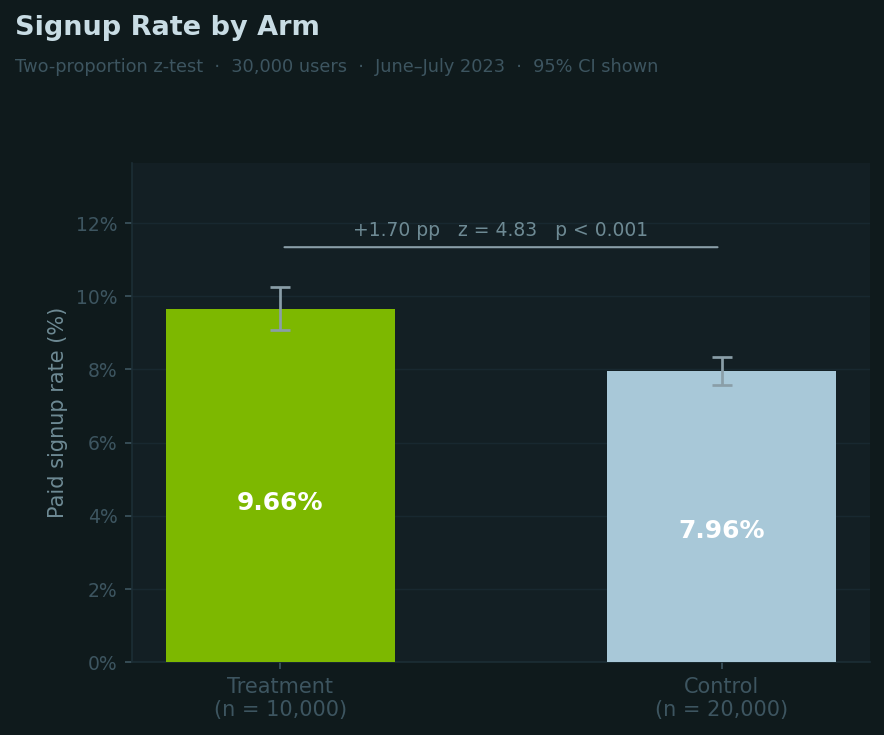

In [20]:
se_t_ = math.sqrt(p_t * (1 - p_t) / n_t)
se_c_ = math.sqrt(p_c * (1 - p_c) / n_c)

fig, ax = plt.subplots(figsize=(6, 5.2))
fig.subplots_adjust(top=0.78, bottom=0.14, left=0.13, right=0.95)

ax.bar([0, 1], [p_t * 100, p_c * 100],
       color=[C['moss'], C['ice']], width=0.52, edgecolor='none', zorder=3)
ax.errorbar([0, 1], [p_t * 100, p_c * 100],
            yerr=[1.96 * se_t_ * 100, 1.96 * se_c_ * 100],
            fmt='none', color=C['stone'], capsize=5, linewidth=1.3, capthick=1.3, zorder=4)

for xi, pr in [(0, p_t), (1, p_c)]:
    ax.text(xi, pr * 100 * 0.45, f'{pr * 100:.2f}%',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

y_top = max(p_t, p_c) * 100 + 1.96 * max(se_t_, se_c_) * 100 + 0.6
ax.annotate('', xy=(1, y_top + 0.5), xytext=(0, y_top + 0.5),
            arrowprops=dict(arrowstyle='-', color=C['stone'], lw=1))
ax.text(0.5, y_top + 0.7, f'+{lift * 100:.2f} pp   z = {z1:.2f}   p < 0.001',
        ha='center', va='bottom', fontsize=9, color=C['muted'], fontfamily=MONO)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Treatment\n(n = 10,000)', 'Control\n(n = 20,000)'], fontsize=10)
ax.set_ylabel('Paid signup rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_ylim(0, y_top + 2.8)
ax.xaxis.grid(False)

add_header(fig, 'Signup Rate by Arm',
           'Two-proportion z-test  ·  30,000 users  ·  June–July 2023  ·  95% CI shown')
save_fig(fig, '00_signup_rate.png')
plt.show()

### Figure 01 — Cancellation Rate: The Artifact and the Reality

saved → figures/01_retention_comparison.png


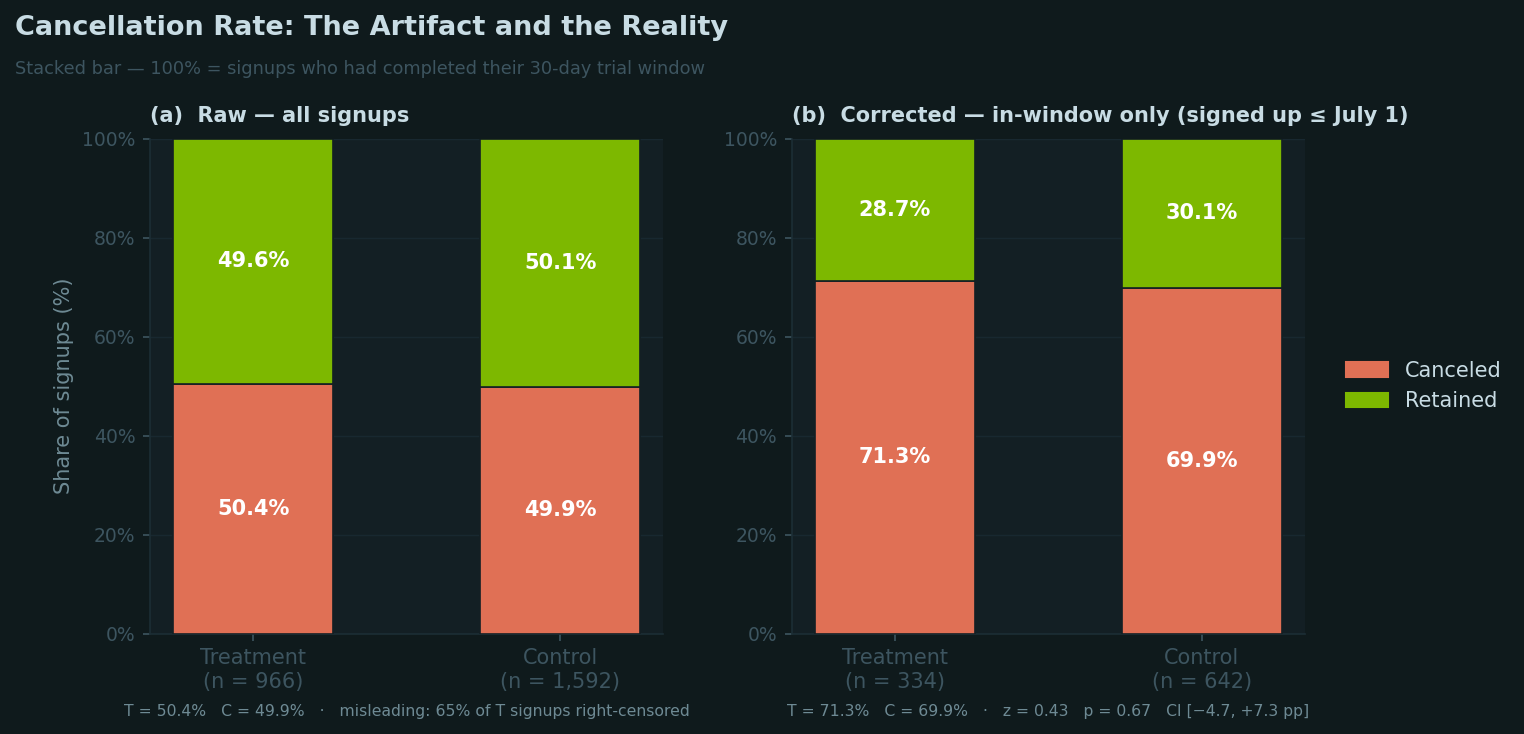

In [22]:
st_all_ = [r for r in treat if r['paid_signup_date']]
sc_all_ = [r for r in ctrl  if r['paid_signup_date']]
pt_raw_ = sum(1 for r in st_all_ if r['paid_plan_canceled'] == '1') / len(st_all_)
pc_raw_ = sum(1 for r in sc_all_ if r['paid_plan_canceled'] == '1') / len(sc_all_)

def _retention_panel(ax, pt, pc, nt_, nc_, title, stats_line):
    ax.bar([0, 1], [pt * 100, pc * 100],
           color=C['rust'], width=0.52, label='Canceled',
           edgecolor=_SURF, linewidth=0.8, zorder=3)
    ax.bar([0, 1], [(1 - pt) * 100, (1 - pc) * 100],
           bottom=[pt * 100, pc * 100],
           color=C['moss'], width=0.52, label='Retained',
           edgecolor=_SURF, linewidth=0.8, zorder=3)
    for xi, pcan, pret in [(0, pt, 1 - pt), (1, pc, 1 - pc)]:
        ax.text(xi, pcan * 50, f'{pcan * 100:.1f}%',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        ax.text(xi, pcan * 100 + pret * 50, f'{pret * 100:.1f}%',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Treatment\n(n = {nt_:,})', f'Control\n(n = {nc_:,})'], fontsize=10)
    ax.xaxis.grid(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, fontweight='bold', color=C['text'], loc='left', pad=8)
    ax.set_xlabel(stats_line, fontsize=7.5, color=C['muted'], fontfamily=MONO, labelpad=6)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
fig.subplots_adjust(top=0.82, bottom=0.22, left=0.09, right=0.86, wspace=0.25)

_retention_panel(axes[0], pt_raw_, pc_raw_, len(st_all_), len(sc_all_),
    '(a)  Raw — all signups',
    f'T = {pt_raw_ * 100:.1f}%   C = {pc_raw_ * 100:.1f}%   ·   misleading: 65% of T signups right-censored')
_retention_panel(axes[1], p_tc, p_cc, len(t_in), len(c_in),
    '(b)  Corrected — in-window only (signed up ≤ July 1)',
    f'T = {p_tc * 100:.1f}%   C = {p_cc * 100:.1f}%   ·   z = 0.43   p = 0.67   CI [−4.7, +7.3 pp]')

axes[0].set_ylabel('Share of signups (%)')
handles = [mpatches.Patch(color=C['rust'], label='Canceled'),
           mpatches.Patch(color=C['moss'], label='Retained')]
fig.legend(handles=handles, loc='center left', ncol=1, frameon=False, fontsize=10,
           bbox_to_anchor=(0.875, 0.52))

add_header(fig, 'Cancellation Rate: The Artifact and the Reality',
           'Stacked bar — 100% = signups who had completed their 30-day trial window')
save_fig(fig, '01_retention_comparison.png')
plt.show()

### Figure 02 — Free-Month Trials vs. Observation Window

saved → figures/02_censoring_timeline.png


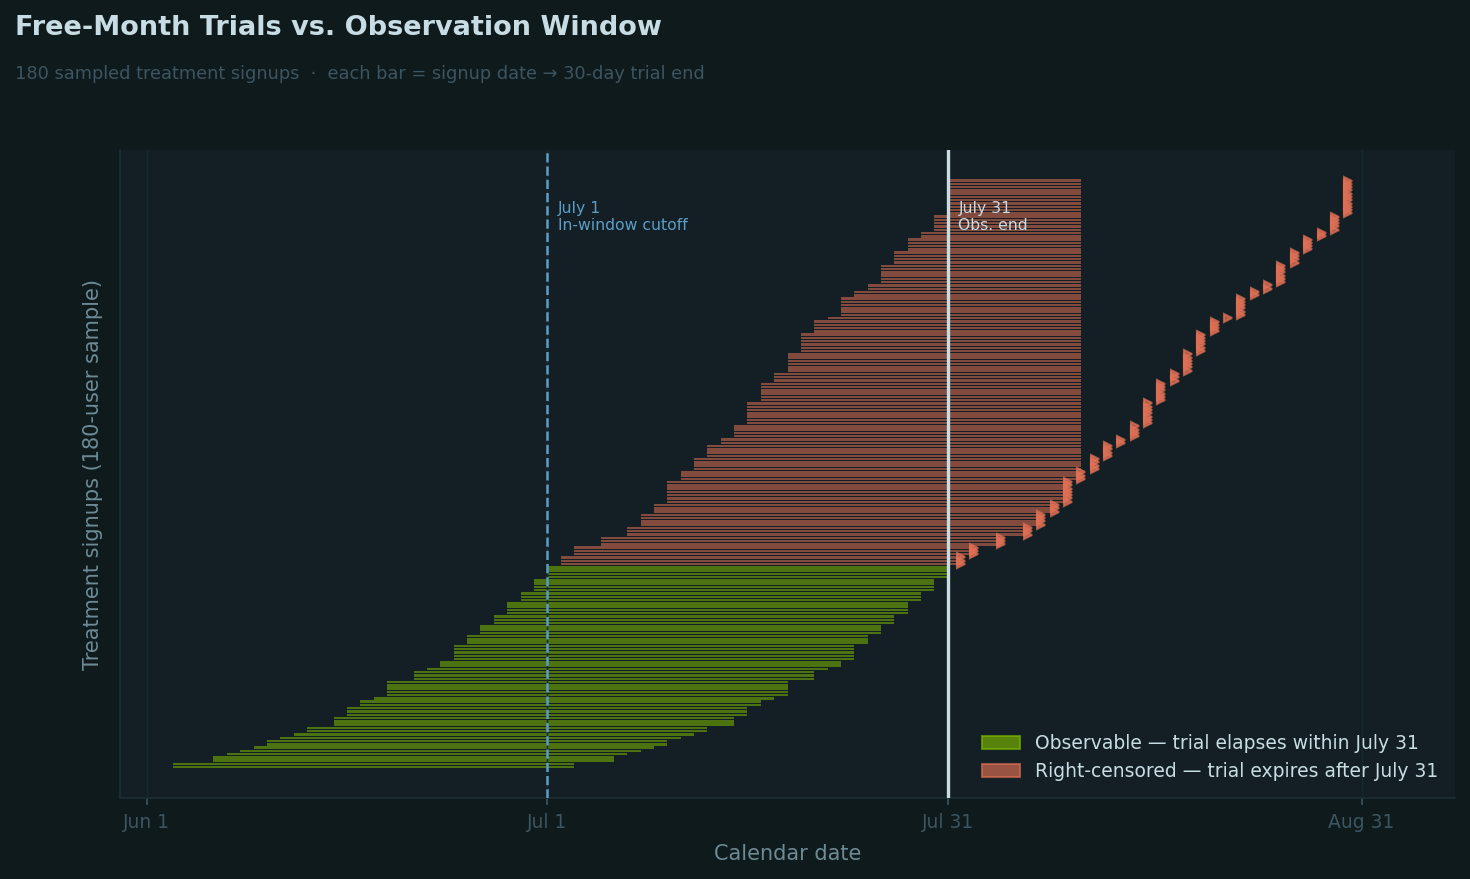

In [23]:
signed_ = [r for r in treat if r['paid_signup_date']]
np.random.seed(42)
idx_    = np.random.choice(len(signed_), min(180, len(signed_)), replace=False)
sample_ = sorted([signed_[i] for i in idx_], key=lambda r: r['paid_signup_date'])

obs_start_ = datetime(2023, 6, 1)
fig, ax    = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(top=0.82, bottom=0.10, left=0.07, right=0.96)

for y, r in enumerate(sample_):
    su       = parse(r['paid_signup_date'])
    te       = su + timedelta(days=30)
    censored = te > OBS_END
    color    = C['rust'] if censored else C['moss']
    end_disp = min(te, datetime(2023, 8, 10))
    ax.barh(y, (end_disp - su).days, left=(su - obs_start_).days,
            height=0.75, color=color, alpha=0.55, linewidth=0)
    if censored:
        ax.plot((te - obs_start_).days, y, '>',
                color=C['rust'], markersize=3.5, alpha=0.75, linewidth=0)

cut_x = (CUTOFF  - obs_start_).days
end_x = (OBS_END - obs_start_).days
ax.axvline(cut_x, color=C['steel'], linewidth=1.2, linestyle='--', zorder=5)
ax.axvline(end_x, color=C['text'],  linewidth=1.6, linestyle='-',  zorder=5)
ax.text(cut_x + 0.8, len(sample_) * 0.96, 'July 1\nIn-window cutoff',
        fontsize=7.5, color=C['steel'], va='top', fontfamily=MONO)
ax.text(end_x + 0.8, len(sample_) * 0.96, 'July 31\nObs. end',
        fontsize=7.5, color=C['text'], va='top', fontfamily=MONO)

tick_dates = [datetime(2023, d[0], d[1]) for d in [(6, 1), (7, 1), (7, 31), (8, 31)]]
ax.set_xticks([(d - obs_start_).days for d in tick_dates])
ax.set_xticklabels([d.strftime('%b %-d') for d in tick_dates])
ax.set_xlim(-2, 98)
ax.set_yticks([])
ax.set_xlabel('Calendar date', labelpad=6)
ax.set_ylabel('Treatment signups (180-user sample)', labelpad=8)
ax.yaxis.grid(False)

handles = [
    mpatches.Patch(color=C['moss'], alpha=0.65, label='Observable — trial elapses within July 31'),
    mpatches.Patch(color=C['rust'], alpha=0.65, label='Right-censored — trial expires after July 31'),
]
ax.legend(handles=handles, frameon=False, fontsize=9, loc='lower right')

add_header(fig, 'Free-Month Trials vs. Observation Window',
           '180 sampled treatment signups  ·  each bar = signup date → 30-day trial end')
save_fig(fig, '02_censoring_timeline.png')
plt.show()

### Figure 03 — Days-to-Signup Distribution

saved → figures/03_days_to_signup.png


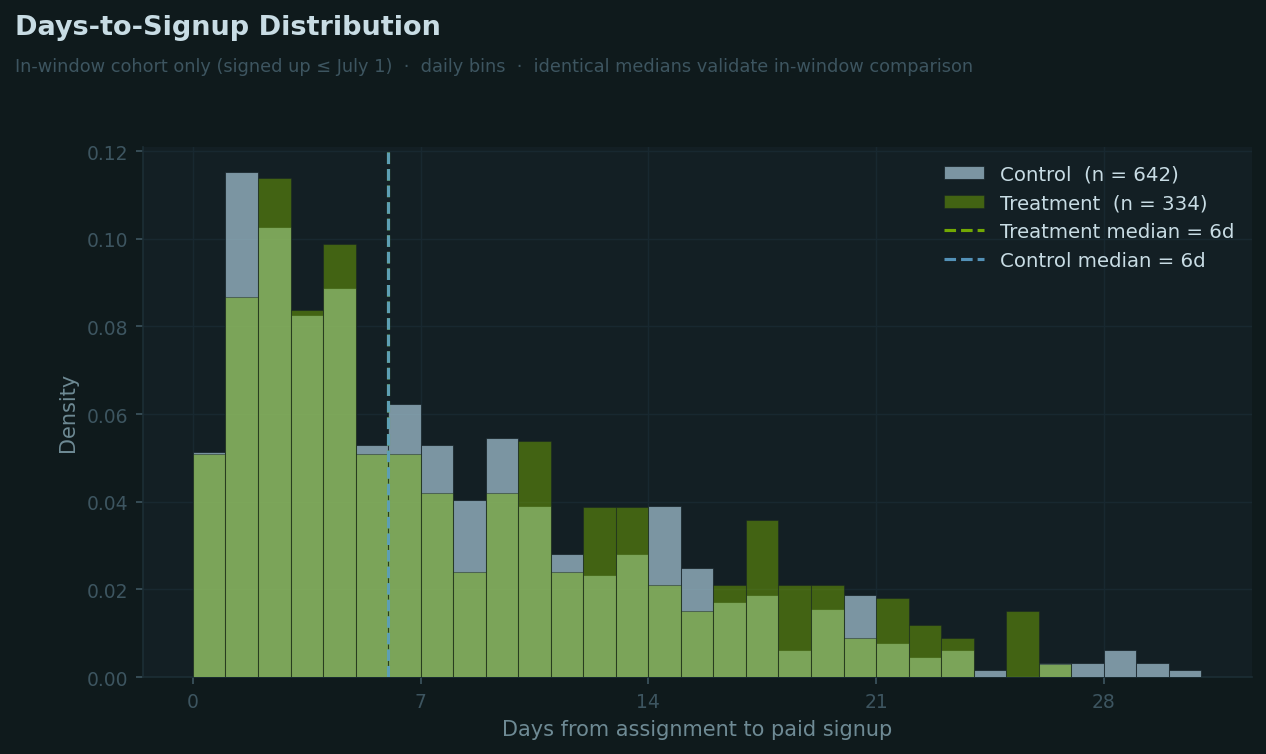

In [24]:
def _d2s(cohort):
    return [(parse(r['paid_signup_date']) - parse(r['assignment_date'])).days
            for r in cohort
            if r['paid_signup_date'] and parse(r['paid_signup_date']) <= CUTOFF]

td2s = _d2s(treat)
cd2s = _d2s(ctrl)
t_med_ = int(np.median(td2s))
c_med_ = int(np.median(cd2s))

fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.10, right=0.97)

bins_ = list(range(0, 32, 1))
kw_   = dict(bins=bins_, density=True, edgecolor=_SURF, linewidth=0.5, zorder=3)
ax.hist(cd2s, color=C['ice'],  alpha=0.70, label=f'Control  (n = {len(cd2s):,})',  **kw_)
ax.hist(td2s, color=C['moss'], alpha=0.45, label=f'Treatment  (n = {len(td2s):,})', **kw_)
ax.axvline(t_med_, color=C['moss'],  linewidth=1.5, linestyle='--', alpha=0.9, zorder=4,
           label=f'Treatment median = {t_med_}d')
ax.axvline(c_med_, color=C['steel'], linewidth=1.5, linestyle='--', alpha=0.9, zorder=4,
           label=f'Control median = {c_med_}d')

ax.set_xlabel('Days from assignment to paid signup')
ax.set_ylabel('Density')
ax.set_xticks(range(0, 32, 7))
ax.legend(frameon=False, fontsize=9.5, loc='upper right')

add_header(fig, 'Days-to-Signup Distribution',
           'In-window cohort only (signed up ≤ July 1)  ·  daily bins  ·'
           '  identical medians validate in-window comparison')
save_fig(fig, '03_days_to_signup.png')
plt.show()

### Figure 04 — Signup Lift by Day of Week

saved → figures/04_dow_lift.png


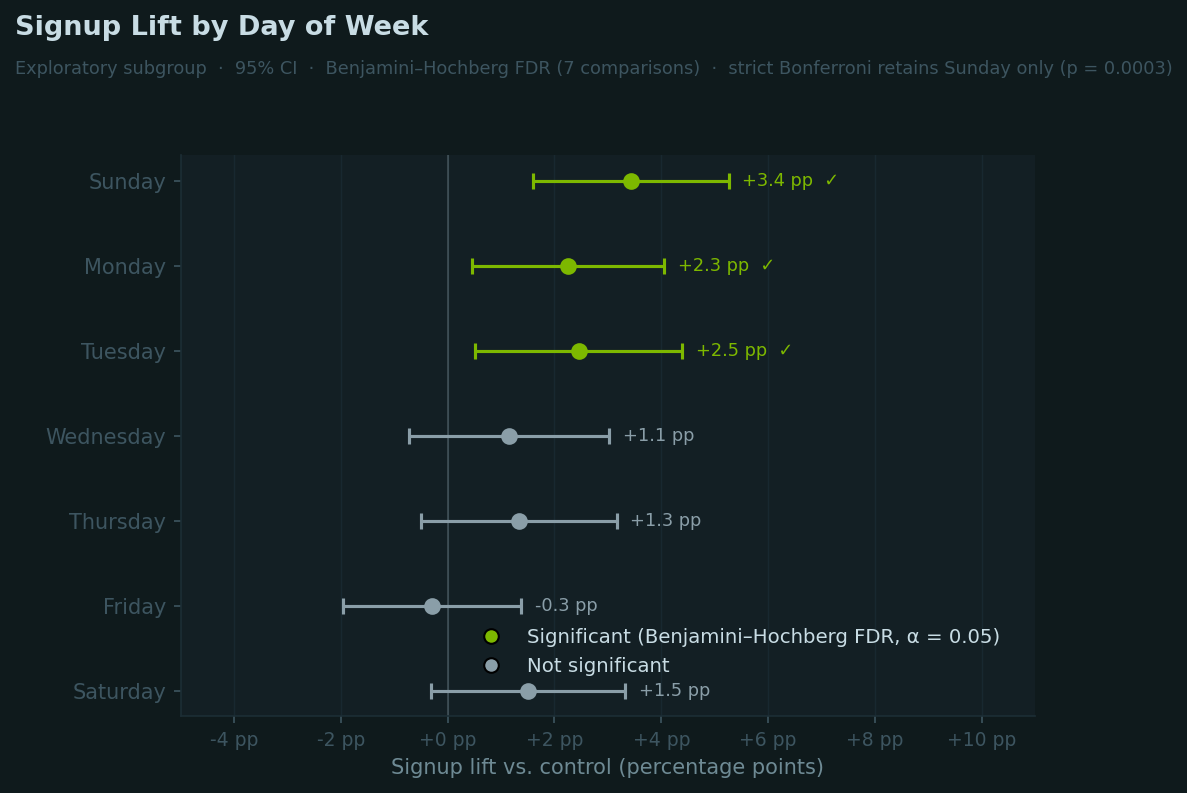

In [25]:
days_order_ = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
t_byd, c_byd = defaultdict(list), defaultdict(list)
for r in treat:
    t_byd[parse(r['assignment_date']).strftime('%A')].append(1 if r['paid_signup_date'] else 0)
for r in ctrl:
    c_byd[parse(r['assignment_date']).strftime('%A')].append(1 if r['paid_signup_date'] else 0)

lifts_, errs_, pvals_ = [], [], []
for day_ in days_order_:
    ta_, ca_ = t_byd[day_], c_byd[day_]
    pt_ = sum(ta_) / len(ta_);  pc_ = sum(ca_) / len(ca_)
    se_ = math.sqrt(pt_*(1-pt_)/len(ta_) + pc_*(1-pc_)/len(ca_))
    z_  = (pt_ - pc_) / se_
    pvals_.append(2 * (1 - stats.norm.cdf(abs(z_))))
    lifts_.append((pt_ - pc_) * 100)
    errs_.append(1.96 * se_ * 100)

m_       = len(days_order_)
ranked_  = sorted(range(m_), key=lambda i: pvals_[i])
sig_     = [False] * m_
for rank_, idx_ in enumerate(ranked_):
    if pvals_[idx_] < (rank_ + 1) / m_ * 0.05:
        sig_[idx_] = True

fig, ax = plt.subplots(figsize=(8.5, 5.5))
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.13, right=0.80)

for i, (day_, lft_, err_, s_) in enumerate(zip(days_order_, lifts_, errs_, sig_)):
    color = C['moss'] if s_ else C['stone']
    ax.errorbar(lft_, i, xerr=err_,
                fmt='o', color=color, markersize=7,
                capsize=4, linewidth=1.5, capthick=1.5,
                zorder=4 if s_ else 3)
    label = f'{lft_:+.1f} pp' + ('  ✓' if s_ else '')
    ax.text(lft_ + err_ + 0.25, i, label,
            va='center', fontsize=8.5, color=color, fontfamily=MONO)

ax.axvline(0, color=C['text'], linewidth=0.8, alpha=0.25, zorder=2)
ax.set_yticks(range(m_))
ax.set_yticklabels(days_order_, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Signup lift vs. control (percentage points)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0f} pp'))
ax.yaxis.grid(False)
ax.set_xlim(-5, 11)

handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=C['moss'],
           markersize=7, label='Significant (Benjamini–Hochberg FDR, α = 0.05)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=C['stone'],
           markersize=7, label='Not significant'),
]
ax.legend(handles=handles, frameon=False, fontsize=9.5, loc='lower right',
          bbox_to_anchor=(0.98, 0.04))

add_header(fig, 'Signup Lift by Day of Week',
           'Exploratory subgroup  ·  95% CI  ·  Benjamini–Hochberg FDR (7 comparisons)'
           '  ·  strict Bonferroni retains Sunday only (p = 0.0003)')
save_fig(fig, '04_dow_lift.png')
plt.show()

### Figure 05 — ROI Break-Even vs. Monthly Churn Rate

saved → figures/05_breakeven_sensitivity.png


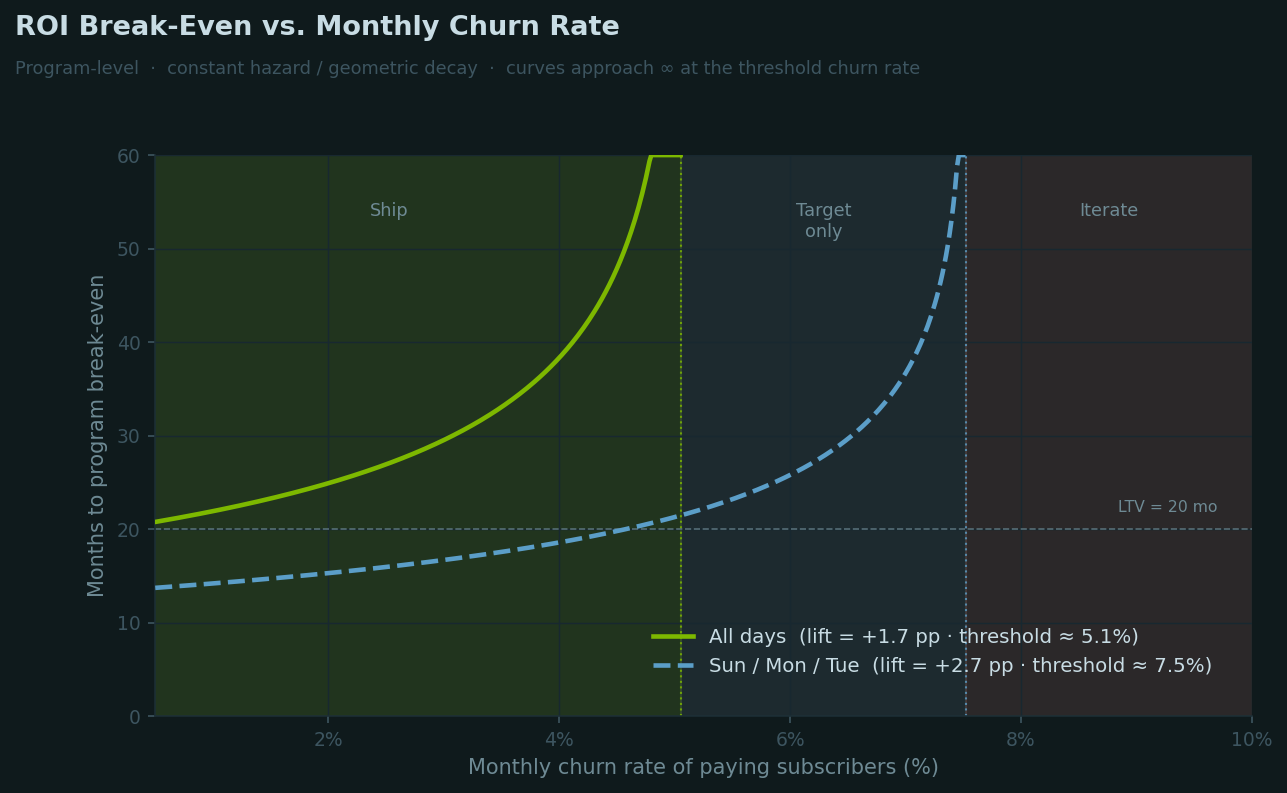

In [21]:
def _be_curve(sr, lft, ret, price, m_arr):
    """Break-even months under geometric (constant-hazard) decay."""
    cost      = sr * 100 * price
    monthly_r = lft * 100 * ret * price
    threshold = cost * m_arr / monthly_r
    be = np.where(
        threshold < 1,
        np.log(np.maximum(1 - threshold, 1e-12)) / np.log(np.maximum(1 - m_arr, 1e-12)),
        np.nan,
    )
    return np.clip(be, 0, 60), monthly_r / cost

m_vals  = np.linspace(0.005, 0.10, 600)
be_all_, thresh_all_ = _be_curve(p_t,     lift,     ret_t, PRICE, m_vals)
be_smt_, thresh_smt_ = _be_curve(sr_t_smt, lift_smt, ret_t, PRICE, m_vals)

t_all_pct = thresh_all_ * 100
t_smt_pct = thresh_smt_ * 100
churn_pct = m_vals * 100

fig, ax = plt.subplots(figsize=(8.5, 5.5))
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.11, right=0.97)

ax.axvspan(0,         t_all_pct, alpha=0.14, color=C['moss'],  zorder=1)
ax.axvspan(t_all_pct, t_smt_pct, alpha=0.09, color=C['stone'], zorder=1)
ax.axvspan(t_smt_pct, 11,        alpha=0.12, color=C['rust'],  zorder=1)

ax.plot(churn_pct, be_all_, color=C['moss'],  linewidth=2.2, zorder=3,
        label=f'All days  (lift = +{lift*100:.1f} pp · threshold ≈ {t_all_pct:.1f}%)')
ax.plot(churn_pct, be_smt_, color=C['steel'], linewidth=2.2, linestyle='--', zorder=3,
        label=f'Sun / Mon / Tue  (lift = +{lift_smt*100:.1f} pp · threshold ≈ {t_smt_pct:.1f}%)')

for xc, color in [(t_all_pct, C['moss']), (t_smt_pct, C['steel'])]:
    ax.axvline(xc, color=color, linewidth=1.0, linestyle=':', zorder=2, alpha=0.8)

for xc_, lb_ in [
    (t_all_pct / 2,               'Ship'),
    ((t_all_pct + t_smt_pct) / 2, 'Target\nonly'),
    ((t_smt_pct + 10) / 2,        'Iterate'),
]:
    ax.text(xc_, 55, lb_, ha='center', fontsize=8.5,
            color=C['muted'], fontfamily=MONO, va='top')

ax.axhline(20, color=C['muted'], linewidth=0.8, linestyle='--', alpha=0.7, zorder=2)
ax.text(9.7, 21.5, 'LTV = 20 mo',
        fontsize=7.5, color=C['muted'], fontfamily=MONO, va='bottom', ha='right')

ax.set_xlim(0.5, 10)
ax.set_ylim(0, 60)
ax.set_xlabel('Monthly churn rate of paying subscribers (%)')
ax.set_ylabel('Months to program break-even')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(frameon=False, fontsize=9.5, loc='lower right', bbox_to_anchor=(0.98, 0.04))

add_header(fig, 'ROI Break-Even vs. Monthly Churn Rate',
           'Program-level  ·  constant hazard / geometric decay  ·'
           '  curves approach ∞ at the threshold churn rate')
save_fig(fig, '05_breakeven_sensitivity.png')
plt.show()